In [8]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

In [9]:
import julia
from julia import Main
Main.eval("using QuadGK")

In [13]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")

<PyCall.jlwrap S_func>

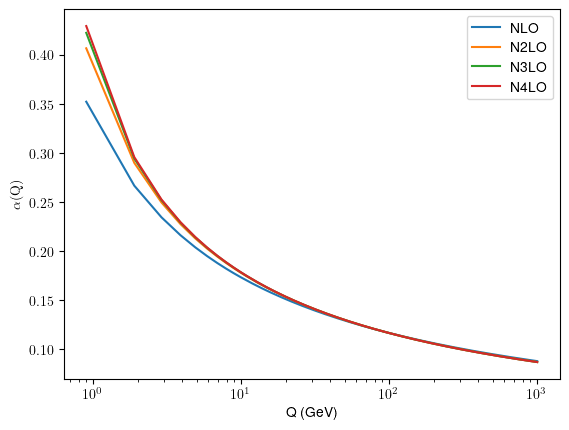

In [12]:
Q = np.arange(0.9, 1000, 1)
length = len(Q)
alpha_1 = np.zeros(length)
alpha_2 = np.zeros(length)
alpha_3 = np.zeros(length)
alpha_4 = np.zeros(length)

for index, q_value in enumerate(Q):
    alpha_1[index] = Main.alpha_s_func(μf=float(q_value), μi=91.1876, αs=0.118, order=1, nf=5)
    alpha_2[index] = Main.alpha_s_func(μf=float(q_value), μi=91.1876, αs=0.118, order=2, nf=5)
    alpha_3[index] = Main.alpha_s_func(μf=float(q_value), μi=91.1876, αs=0.118, order=3, nf=5)
    alpha_4[index] = Main.alpha_s_func(μf=float(q_value), μi=91.1876, αs=0.118, order=4, nf=5)

plt.plot(Q,alpha_1,label="NLO")
plt.plot(Q,alpha_2,label="N2LO")
plt.plot(Q,alpha_3,label="N3LO")
plt.plot(Q,alpha_4,label="N4LO")

plt.xscale('log')  
plt.xlabel('Q (GeV)')
plt.ylabel(r"\rm $\alpha(\rm{Q})$")

plt.legend()
plt.show()

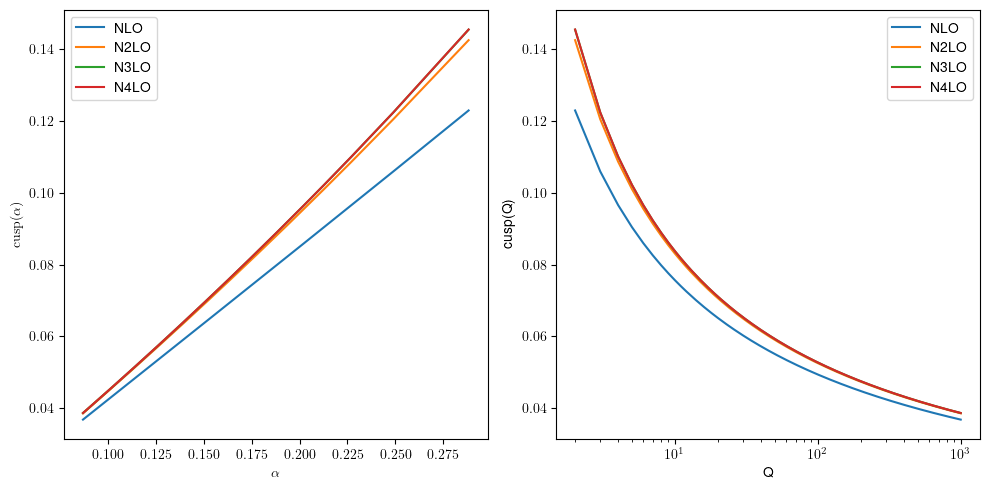

In [76]:
length = len(alpha_4)
cusp_1 = np.zeros(length)
cusp_2 = np.zeros(length)
cusp_3 = np.zeros(length)
cusp_4 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    cusp_1[index] = Main.Γ_func(αs=float(alpha_value), order=1, nf=5)
    cusp_2[index] = Main.Γ_func(αs=float(alpha_value), order=2, nf=5)
    cusp_3[index] = Main.Γ_func(αs=float(alpha_value), order=3, nf=5)
    cusp_4[index] = Main.Γ_func(αs=float(alpha_value), order=4, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, cusp_1, label="NLO")
ax1.plot(alpha_3, cusp_2, label="N2LO")
ax1.plot(alpha_3, cusp_3, label="N3LO")
ax1.plot(alpha_3, cusp_4, label="N4LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm cusp($\alpha$)")
ax1.legend()

ax2.plot(Q, cusp_1, label="NLO")
ax2.plot(Q, cusp_2, label="N2LO")
ax2.plot(Q, cusp_3, label="N3LO")
ax2.plot(Q, cusp_4, label="N4LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('cusp(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

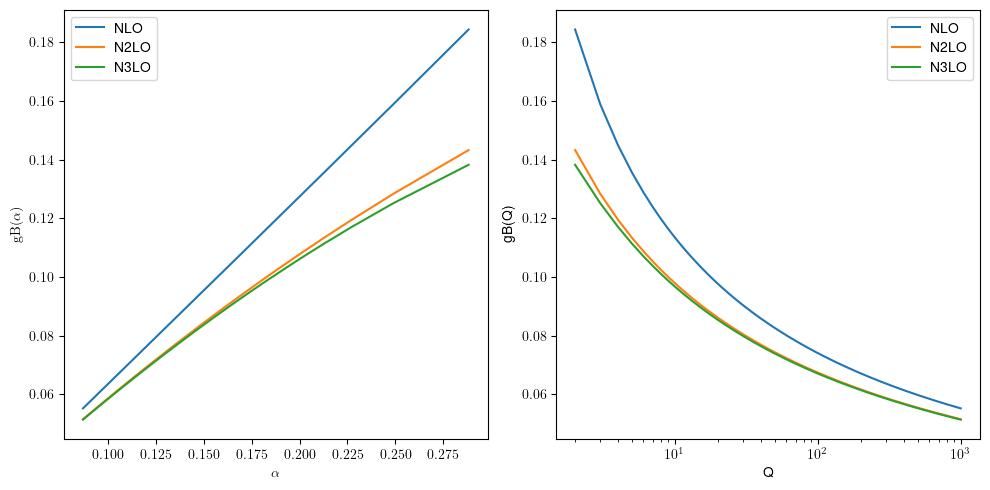

In [77]:
length = len(alpha_4)
γB_1 = np.zeros(length)
γB_2 = np.zeros(length)
γB_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    γB_1[index] = Main.γB_func(αs=float(alpha_value), order=1, nf=5)
    γB_2[index] = Main.γB_func(αs=float(alpha_value), order=2, nf=5)
    γB_3[index] = Main.γB_func(αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, γB_1, label="NLO")
ax1.plot(alpha_3, γB_2, label="N2LO")
ax1.plot(alpha_3, γB_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm gB($\alpha$)")
ax1.legend()

ax2.plot(Q, γB_1, label="NLO")
ax2.plot(Q, γB_2, label="N2LO")
ax2.plot(Q, γB_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('gB(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

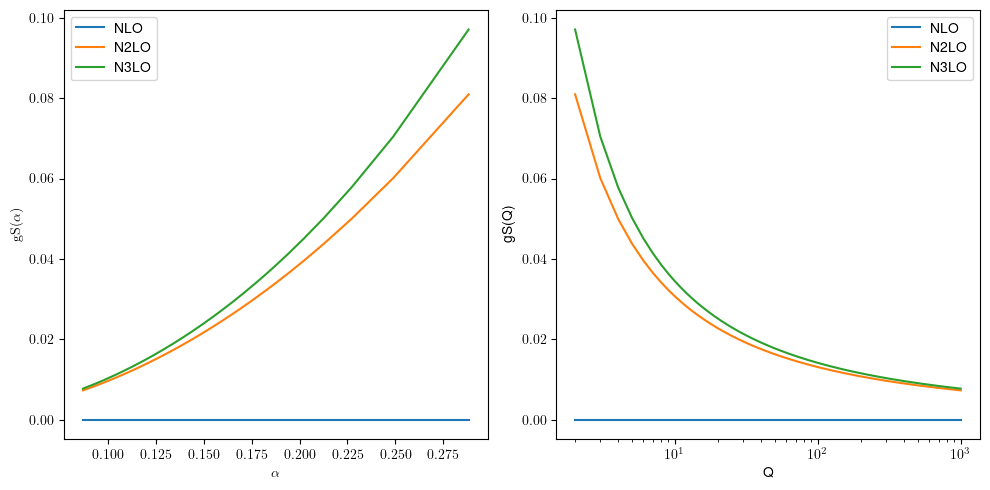

In [78]:
length = len(alpha_4)
γS_1 = np.zeros(length)
γS_2 = np.zeros(length)
γS_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    γS_1[index] = Main.γS_func(αs=float(alpha_value), order=1, nf=5)
    γS_2[index] = Main.γS_func(αs=float(alpha_value), order=2, nf=5)
    γS_3[index] = Main.γS_func(αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, γS_1, label="NLO")
ax1.plot(alpha_3, γS_2, label="N2LO")
ax1.plot(alpha_3, γS_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm gS($\alpha$)")
ax1.legend()

ax2.plot(Q, γS_1, label="NLO")
ax2.plot(Q, γS_2, label="N2LO")
ax2.plot(Q, γS_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('gS(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

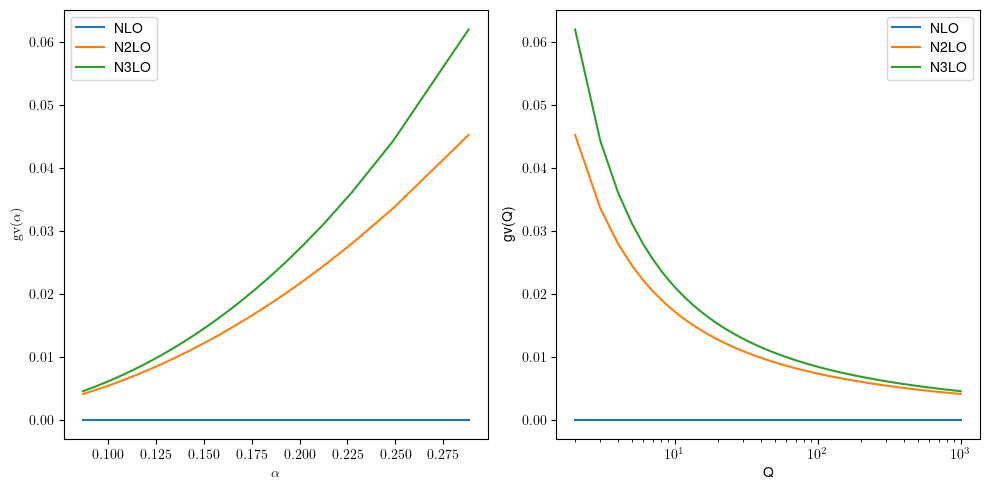

In [79]:
length = len(alpha_4)
γν_1 = np.zeros(length)
γν_2 = np.zeros(length)
γν_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    γν_1[index] = Main.γν_func(αs=float(alpha_value), order=1, nf=5)
    γν_2[index] = Main.γν_func(αs=float(alpha_value), order=2, nf=5)
    γν_3[index] = Main.γν_func(αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, γν_1, label="NLO")
ax1.plot(alpha_3, γν_2, label="N2LO")
ax1.plot(alpha_3, γν_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm gv($\alpha$)")
ax1.legend()

ax2.plot(Q, γν_1, label="NLO")
ax2.plot(Q, γν_2, label="N2LO")
ax2.plot(Q, γν_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('gv(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

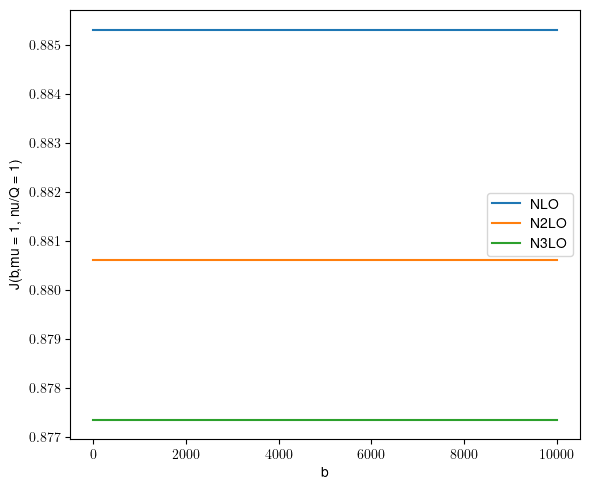

In [80]:
length = 1000

J_1 = np.zeros(length)
J_2 = np.zeros(length)
J_3 = np.zeros(length)

b0 = 1.12292
b_list = np.linspace(0.1,10000,length)

for index, bp in enumerate(b_list):
    J_1[index] = Main.J_func(b=bp, μ = b0/bp, νdQ=1.0, αs=0.118, order=1, nf=5)
    J_2[index] = Main.J_func(b=bp, μ = b0/bp, νdQ=1.0, αs=0.118, order=2, nf=5)
    J_3[index] = Main.J_func(b=bp, μ = b0/bp, νdQ=1.0, αs=0.118, order=3, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, J_1, label="NLO")
ax1.plot(b_list, J_2, label="N2LO")
ax1.plot(b_list, J_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('J(b,mu = 1, nu/Q = 1)')
ax1.legend()

plt.tight_layout()  
plt.show()

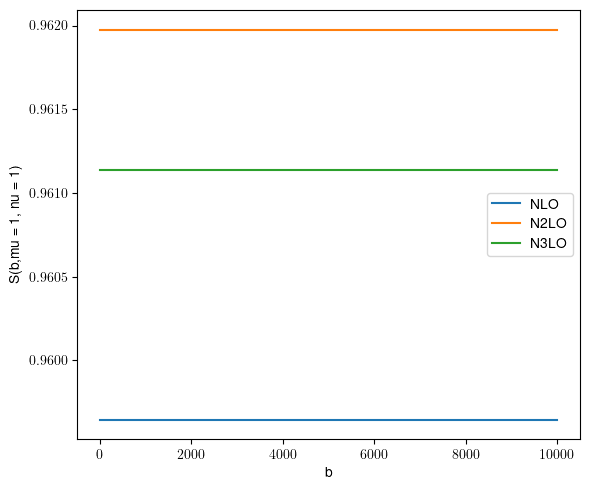

In [81]:
length = 1000

S_1 = np.zeros(length)
S_2 = np.zeros(length)
S_3 = np.zeros(length)

b0 = 1.12292
b_list = np.linspace(0.1,10000,length)

for index, bp in enumerate(b_list):
    S_1[index] = Main.S_func(b=bp, μ = b0/bp, ν=2*b0/bp, αs=0.118, order=1, nf=5)
    S_2[index] = Main.S_func(b=bp, μ = b0/bp, ν=2*b0/bp, αs=0.118, order=2, nf=5)
    S_3[index] = Main.S_func(b=bp, μ = b0/bp, ν=2*b0/bp, αs=0.118, order=3, nf=5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, S_1, label="NLO")
ax1.plot(b_list, S_2, label="N2LO")
ax1.plot(b_list, S_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('S(b,mu = 1, nu = 1)')
ax1.legend()

plt.tight_layout()  
plt.show()

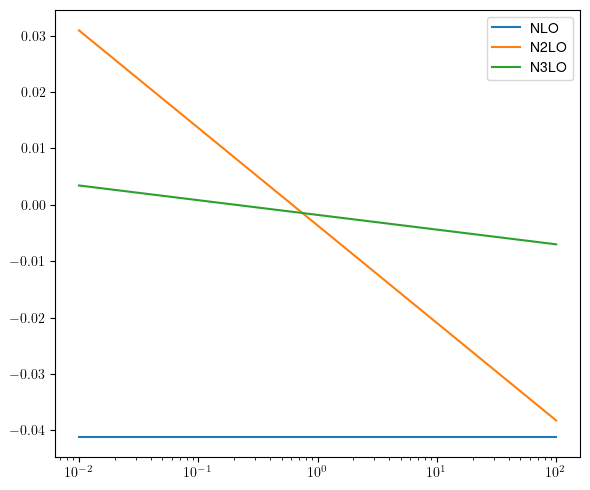

In [87]:
length = 1000

S_1 = np.zeros(length)
S_2 = np.zeros(length)
S_3 = np.zeros(length)

b0 = 1.12292
nu_list = np.linspace(0.01,100,length)

for index, nu in enumerate(nu_list):
    S_1[index] = (0.118/(4*(np.pi))) * Main.S1_func(0,np.log((1/b0)**2/(nu**2)),5)
    S_2[index] = (0.118/(4*(np.pi)))**2 * Main.S2_func(0,np.log((1/b0)**2/(nu**2)),5)
    S_3[index] = (0.118/(4*(np.pi)))**3  * Main.S3_func(0,np.log((1/b0)**2/(nu**2)),5)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(nu_list, S_1, label="NLO")
ax1.plot(nu_list, S_2, label="N2LO")
ax1.plot(nu_list, S_3, label="N3LO")
#ax1.set_xlabel('1/ν^2')
#ax1.set_ylabel('S(b = b0, mu = b0/b, nu)')
ax1.legend()
ax1.set_xscale('log')  
plt.tight_layout()  
plt.show()

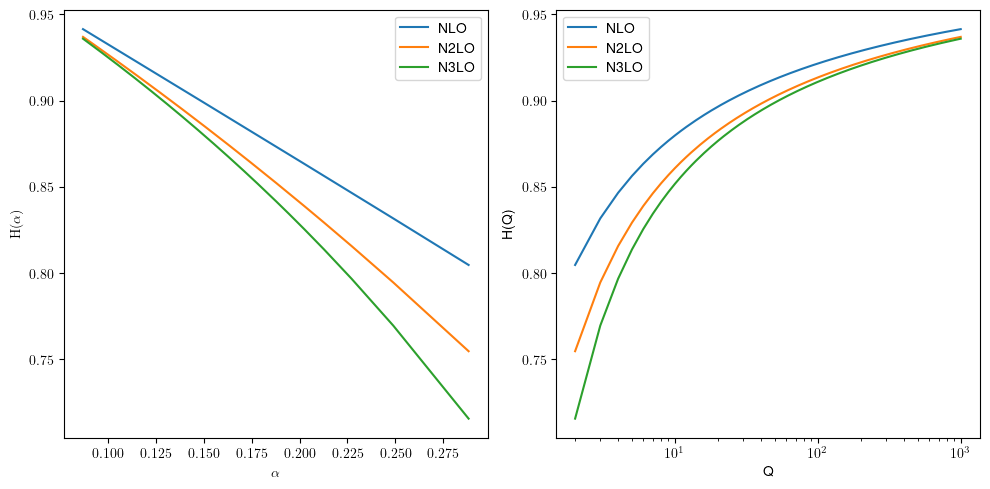

In [85]:
length = len(alpha_3)
H_1 = np.zeros(length)
H_2 = np.zeros(length)
H_3 = np.zeros(length)

for index, alpha_value in enumerate(alpha_4):
    H_1[index] = Main.H_func(μ=float(1*q_value)**2.0, Q=float(q_value)**2.0, αs=float(alpha_value), order=1, nf=5)
    H_2[index] = Main.H_func(μ=float(1*q_value)**2.0, Q=float(q_value)**2.0, αs=float(alpha_value), order=2, nf=5)
    H_3[index] = Main.H_func(μ=float(1*q_value)**2.0, Q=float(q_value)**2.0, αs=float(alpha_value), order=3, nf=5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5)) 

ax1.plot(alpha_3, H_1, label="NLO")
ax1.plot(alpha_3, H_2, label="N2LO")
ax1.plot(alpha_3, H_3, label="N3LO")
ax1.set_xlabel(r"\rm $\alpha$")
ax1.set_ylabel(r"\rm H($\alpha$)")
ax1.legend()

ax2.plot(Q, H_1, label="NLO")
ax2.plot(Q, H_2, label="N2LO")
ax2.plot(Q, H_3, label="N3LO")
ax2.set_xlabel('Q')
ax2.set_ylabel('H(Q)')
ax2.set_xscale('log')  
ax2.legend()

plt.tight_layout()  
plt.show()

In [86]:
cT1 = Main.cT1_func(5)
cT2 = Main.cT2_func(5)
cT3 = Main.cT3_func(5)
print(np.exp((0.118/(4*(np.pi)))*cT1))
print(np.exp((0.118/(4*(np.pi)))*cT1+(0.118/(4*(np.pi)))**2*cT2))
print(np.exp((0.118/(4*(np.pi)))*cT1+(0.118/(4*(np.pi)))**2*cT2+(0.118/(4*(np.pi)))**3*cT3))

0.9596470978487073
0.9569821949893775
0.9553964894682108


In [15]:
length = 1000

J_1 = np.zeros(length)
J_2 = np.zeros(length)
J_3 = np.zeros(length)

b0 = 1.12292
b_list = np.linspace(0.01,10,length)

for index, bp in enumerate(b_list):
    J_1[index] = Main.γν_func(b=bp, μ=10.0, αs_ini=0.118, μ_ini=91.2, order=1, nf=5, bmax=b0)
    J_2[index] = Main.γν_func(b=bp, μ=10.0, αs_ini=0.118, μ_ini=91.2, order=2, nf=5, bmax=b0)
    J_3[index] = Main.γν_func(b=bp, μ=10.0, αs_ini=0.118, μ_ini=91.2, order=3, nf=5, bmax=b0)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5)) 

ax1.plot(b_list, J_1, label="NLO")
ax1.plot(b_list, J_2, label="N2LO")
ax1.plot(b_list, J_3, label="N3LO")
ax1.set_xlabel('b')
ax1.set_ylabel('J(b,mu = 1, nu/Q = 1)')
ax1.legend()

plt.tight_layout()  
plt.show()

TypeError: <PyCall.jlwrap (in a Julia function called from Python)
JULIA: TypeError: in keyword argument bmax, expected Int64, got a value of type Float64
Stacktrace:
 [1] #invokelatest#2
   @ .\essentials.jl:894 [inlined]
 [2] _pyjlwrap_call(f::Function, args_::Ptr{PyCall.PyObject_struct}, kw_::Ptr{PyCall.PyObject_struct})
   @ PyCall C:\Users\15652\.julia\packages\PyCall\1gn3u\src\callback.jl:32
 [3] pyjlwrap_call(self_::Ptr{PyCall.PyObject_struct}, args_::Ptr{PyCall.PyObject_struct}, kw_::Ptr{PyCall.PyObject_struct})
   @ PyCall C:\Users\15652\.julia\packages\PyCall\1gn3u\src\callback.jl:44>